# Sleep health — participant-level analysis

**SIADS 699 Capstone · Team Sleep Deprived**
Sophia Boettcher · Auston Balwinski · Hunter Belous · Jared Fox

---
Predicts sleep duration and sleep consistency from the participant-level frame that
[`data_extraction.ipynb`](data_extraction.ipynb) builds: explore, select one feature set, run every
model against it, interpret, and audit fairness by subgroup.

Logic lives in [`src/features.py`](../src/features.py), [`src/models.py`](../src/models.py) and
[`src/viz.py`](../src/viz.py).

Every model is scored on the same feature matrix, so differences across the results table are
attributable to the estimator.

---
## 1 · Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

# Works whether the kernel starts in notebooks/ or at the repo root.
REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from src import cluster, features, models, viz

TARGETS = ["target_sleep_duration", "target_sleep_consistency"]


def _short(target):
    """"target_sleep_consistency" -> "consistency", for figure labels."""
    return target.replace("target_sleep_", "")


In [2]:
PKL = REPO / "data" / "feats_data.pkl"
if not PKL.exists():
    raise FileNotFoundError(f"{PKL} is missing — run data_extraction.ipynb and download the result.")

feats = pd.read_pickle(PKL)

assert feats["person_id"].is_unique, "duplicate person_id in features"
assert "race_ethnicity" in feats.columns, (
    "frame is not recoded — data_extraction.ipynb applies clean_demographics() before export"
)
assert feats["n_valid_nights"].min() >= features.MIN_MODEL_NIGHTS, (
    f"extract is not restricted to >= {features.MIN_MODEL_NIGHTS} nights — this pickle "
    f"predates the restriction moving into data_extraction.ipynb; re-run it"
)

print(f"{len(feats):,} participants x {feats.shape[1]} columns "
      f"(>= {features.MIN_MODEL_NIGHTS} valid nights; described in data_extraction.ipynb §13)")

45,259 participants x 22 columns (>= 30 valid nights; described in data_extraction.ipynb §13)


---
## 2 · Exploration

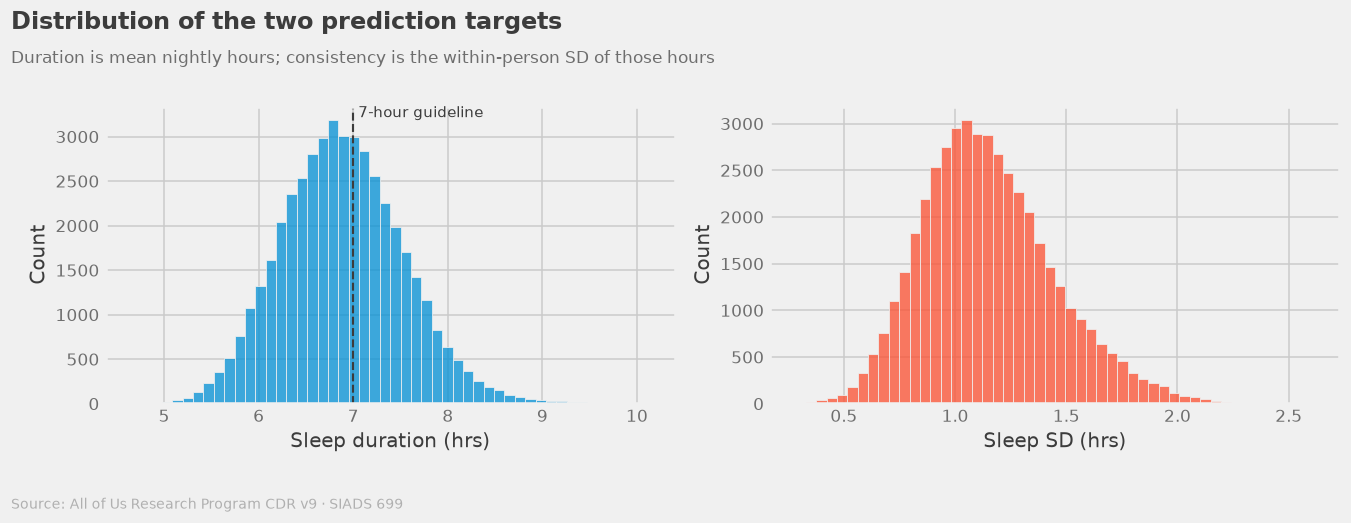

In [3]:
viz.plot_targets(feats)

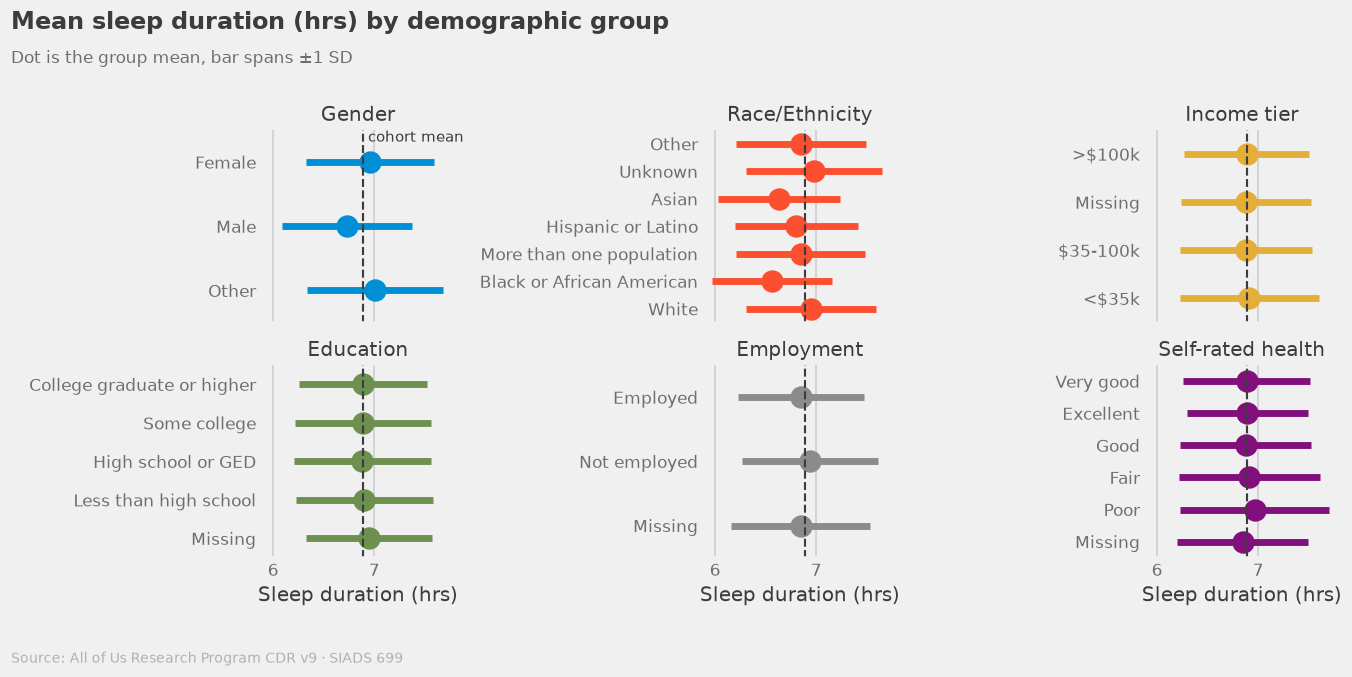

In [4]:

viz.plot_group_means(
    feats,
    [c for c in models.CATEGORICAL_COLS if c in feats.columns],
    TARGETS[0],
)


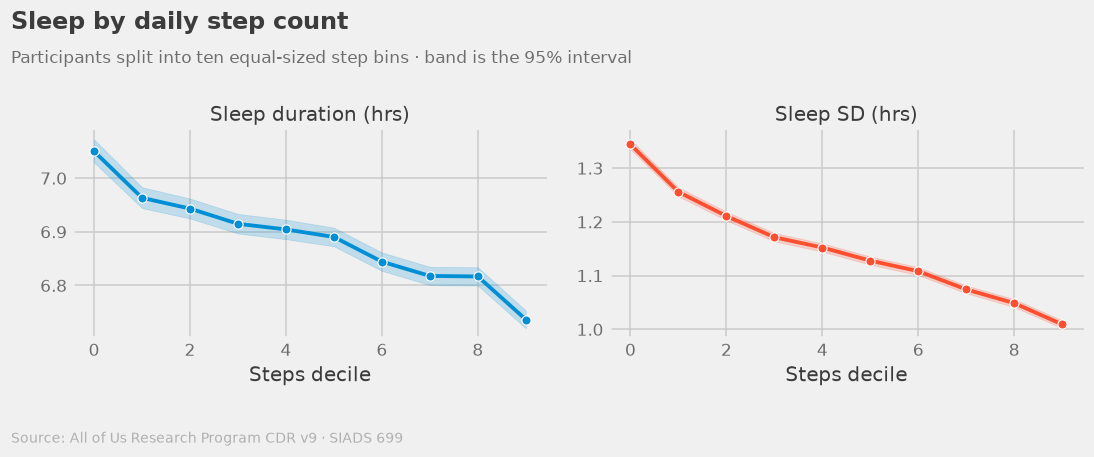

In [5]:
viz.plot_activity_gradient(feats)

---
## 3 · Feature construction

`make_model_features()` derives the modelling columns from the aggregated frame. It adds columns and
drops nothing, so the extract is still intact underneath.

In [6]:
model_df = features.make_model_features(feats)

added = [c for c in model_df.columns if c not in feats.columns]
pd.DataFrame({
    "dtype":  model_df[added].dtypes.astype(str),
    "nulls":  model_df[added].isna().sum(),
    "null %": (model_df[added].isna().mean() * 100).round(1),
})

,dtype,nulls,null %
log_steps,float64,267,0.6
steps_cv,float64,267,0.6
employed,float64,305,0.7
education_num,float64,336,0.7
health_num,float64,1013,2.2
income_num,float64,2745,6.1
age_band,category,0,0.0


---
## 4 · Feature selection

### Rule 1 — leakage

Drop anything computed from the same nightly distribution as the targets. A model given
`iqr_sleep_hrs` is largely predicting a target from itself.

`n_valid_nights` is the one sleep-derived column kept. It counts nights rather than summarising
their durations, so it carries wear-time information instead of outcome information.

In [7]:
sleep_derived = sorted(
    c for c in model_df.columns
    if ("sleep" in c or c in models.LEAKY_COLS) and c != "n_valid_nights"
)
print(f"excluded as leaky ({len(sleep_derived)}):")
for c in sleep_derived:
    print(f"  {c}")


excluded as leaky (7):
  iqr_sleep_hrs
  mean_sleep_hrs
  pct_long_sleep
  pct_short_sleep
  std_sleep_hrs
  target_sleep_consistency
  target_sleep_duration


### Rule 2 — collinearity

Drop columns that measure what another column already measures: **no pair above |r| = 0.9**, keeping
the best-predicting member of each cluster. The table below is what each rule removed.

In [8]:
# Every column the two rules considered, so the table shows what each one removed.
CANDIDATE_COLS = ["age", "bmi", "mean_daily_steps", "median_daily_steps", "std_daily_steps",
                  "pct_active_days", "log_steps", "steps_cv", "n_valid_nights", "n_valid_days",
                  "employed", "education_num", "health_num", "income_num"]

# Both feature matrices, built once here and read from XY everywhere below.
XY = {target: models.prepare_X_y(model_df, target) for target in TARGETS}
X_duration, _ = XY[TARGETS[0]]

pd.DataFrame({
    "max |r| before prune": models.max_correlations(model_df[CANDIDATE_COLS]).round(3),
    "max |r| after prune":  models.max_correlations(X_duration).round(3),
}).sort_values("max |r| before prune", ascending=False).head(10).fillna("— dropped")


,max |r| before prune,max |r| after prune
mean_daily_steps,0.987,— dropped
median_daily_steps,0.987,— dropped
pct_active_days,0.933,— dropped
log_steps,0.924,0.483
n_valid_days,0.904,— dropped
n_valid_nights,0.904,0.219
std_daily_steps,0.739,— dropped
steps_cv,0.521,0.483
bmi,0.373,0.373
health_num,0.373,0.373


`mean_daily_steps` and `median_daily_steps` correlate 0.987, and a model given both uses them as a difference operator, 
so the coefficients belong to that difference rather than to either column. 
The wear-time pair behaves the same way: `n_valid_nights` and `n_valid_days` correlate 0.904, and their difference is a device-usage pattern rather than a sleep behaviour.

What survives is `log_steps` for activity level, `steps_cv` (std / mean) for irregularity and `n_valid_nights`
alone for wear time. Interaction terms were screened separately and none earned a column.

### The feature contract

What survives both rules, with assertions as tripwires.

In [9]:
corr_max = models.max_correlations(X_duration).max()
cond = models.condition_number(X_duration)
n_dummies = X_duration.shape[1] - len(models.FEATURE_COLS)

# sleep_derived is a superset of LEAKY_COLS, so one check covers both rules.
assert not set(models.FEATURE_COLS) & set(sleep_derived), \
    "sleep-derived column in the feature list"
assert not set(models.FEATURE_COLS) & set(models.GROUP_COLS), \
    "a fairness stratum is also a model feature"
assert not set(models.FEATURE_COLS) & set(models.ENCODE_COLS), \
    "column is both numeric and one-hot encoded"
assert corr_max < 0.9, f"collinearity: max |r| {corr_max:.2f}"
assert cond < 30, f"ill-conditioned design matrix: {cond:.1f}"

print(f"{len(models.FEATURE_COLS)} numeric + {n_dummies} dummies "
      f"from {models.ENCODE_COLS} = {X_duration.shape[1]} columns")
print(f"max |r| {corr_max:.3f}   condition number {cond:.2f}")


9 numeric + 8 dummies from ['gender', 'race_ethnicity'] = 17 columns
max |r| 0.532   condition number 5.22


---
## 5 · Models

5-fold CV, one row per participant, so no split puts the same person on
both sides. Imputation and scaling happen inside the pipeline, so each fold's median and mean are
learned from its training half only.

Because the features are held fixed, the spread across this table is attributable to model class.

In [10]:
results = {target: models.run_all_models(model_df, target) for target in TARGETS}

pd.concat([r.assign(target=t) for t, r in results.items()]).set_index(["target", "Model"])[
    ["rmse_mean", "rmse_std", "mae_mean", "r2_mean"]
].round(4)


  Running Baseline (mean)...
  Running Ridge...
  Running Random Forest...
  Running HistGBM...
  Running Baseline (mean)...
  Running Ridge...
  Running Random Forest...
  Running HistGBM...


rmse_mean  rmse_std  mae_mean  \
target                   Model                                            
target_sleep_duration    HistGBM             0.6117    0.0062    0.4821   
                         Ridge               0.6119    0.0053    0.4826   
                         Random Forest       0.6147    0.0068    0.4848   
                         Baseline (mean)     0.6463    0.0089    0.5129   
target_sleep_consistency HistGBM             0.2520    0.0019    0.1984   
                         Random Forest       0.2534    0.0020    0.1997   
                         Ridge               0.2566    0.0013    0.2019   
                         Baseline (mean)     0.2964    0.0024    0.2350   

                                          r2_mean  
target                   Model                     
target_sleep_duration    HistGBM           0.1039  
                         Ridge             0.1034  
                         Random Forest     0.0950  
                         Baseline (mean)  -0.0001  
target_sleep_consistency HistGBM           0.2773  
                         Random Forest     0.2691  
                         Ridge             0.2503  
                         Baseline (mean)  -0.0001

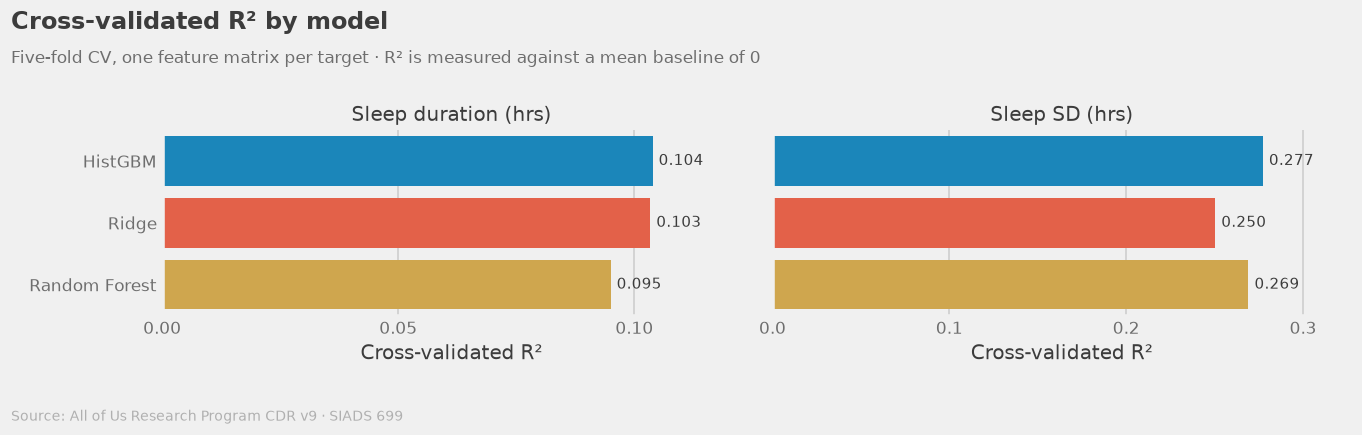

In [11]:
viz.plot_model_comparison(results)

On sleep duration a regularized
linear model and a boosted tree tie, so what limits duration prediction
is missing information rather than model form. On consistency boosting is worth about 11%, so there
is real nonlinear structure in what makes someone's sleep regular.

### Held-out check

The feature set was chosen using cross-validated scores, so those scores carry some selection
optimism. A split the model never saw is the check on it.

In [12]:
holdout_rows = []
for target in TARGETS:
    X, y = XY[target]
    for name in ["Ridge", "HistGBM"]:
        holdout_rows.append({
            "target": _short(target),
            "model":  name,
            "CV R²":  round(results[target].set_index("Model").loc[name, "r2_mean"], 4),
            "held-out R²": round(models.holdout_score(X, y, models.get_model(name)), 4),
        })

holdout = pd.DataFrame(holdout_rows)
holdout["difference"] = (holdout["held-out R²"] - holdout["CV R²"]).round(4)
holdout.set_index(["target", "model"])


CV R²  held-out R²  difference
target      model                                   
duration    Ridge    0.1034       0.1049      0.0015
            HistGBM  0.1039       0.1051      0.0012
consistency Ridge    0.2503       0.2605      0.0102
            HistGBM  0.2773       0.2805      0.0032

The held-out figures land slightly above the cross-validated ones, so choosing the feature set on CV
scores did not inflate them. A single 20% split varies by more than the selection optimism it is
looking for, which makes this corroboration rather than proof, nothing here indicates
overfitting.


---
## 6 · Interpretation

**Ridge coefficients** (left) give direction and magnitude. Features are standardized inside the
pipeline, so they are comparable across columns, and the collinearity prune is what makes them
readable.

**Permutation importance on HistGBM** (right) gives reliance: how much R² the best model loses when a
column is shuffled.

They answer different questions: "which way, and how much" against "what is lost if this goes"

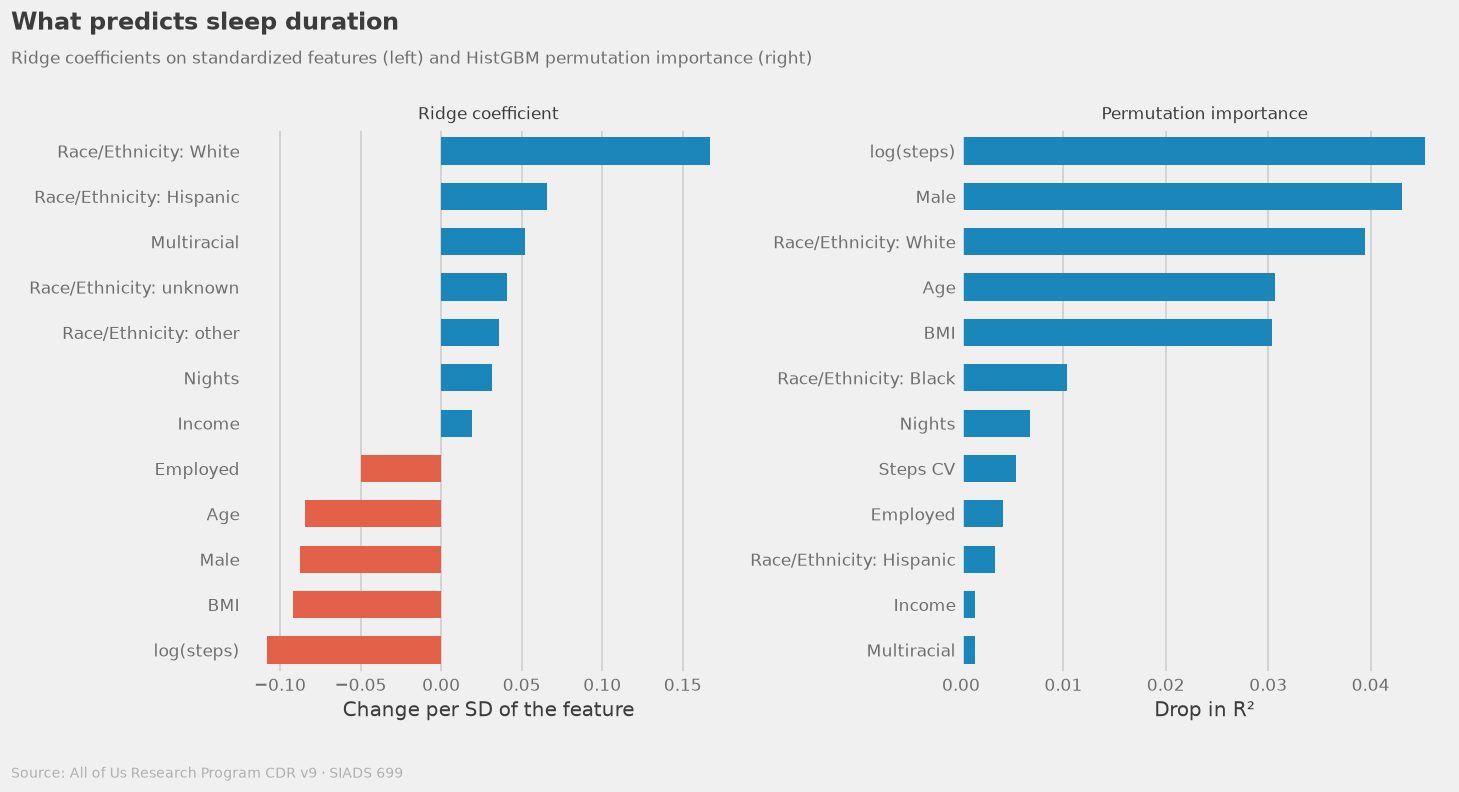

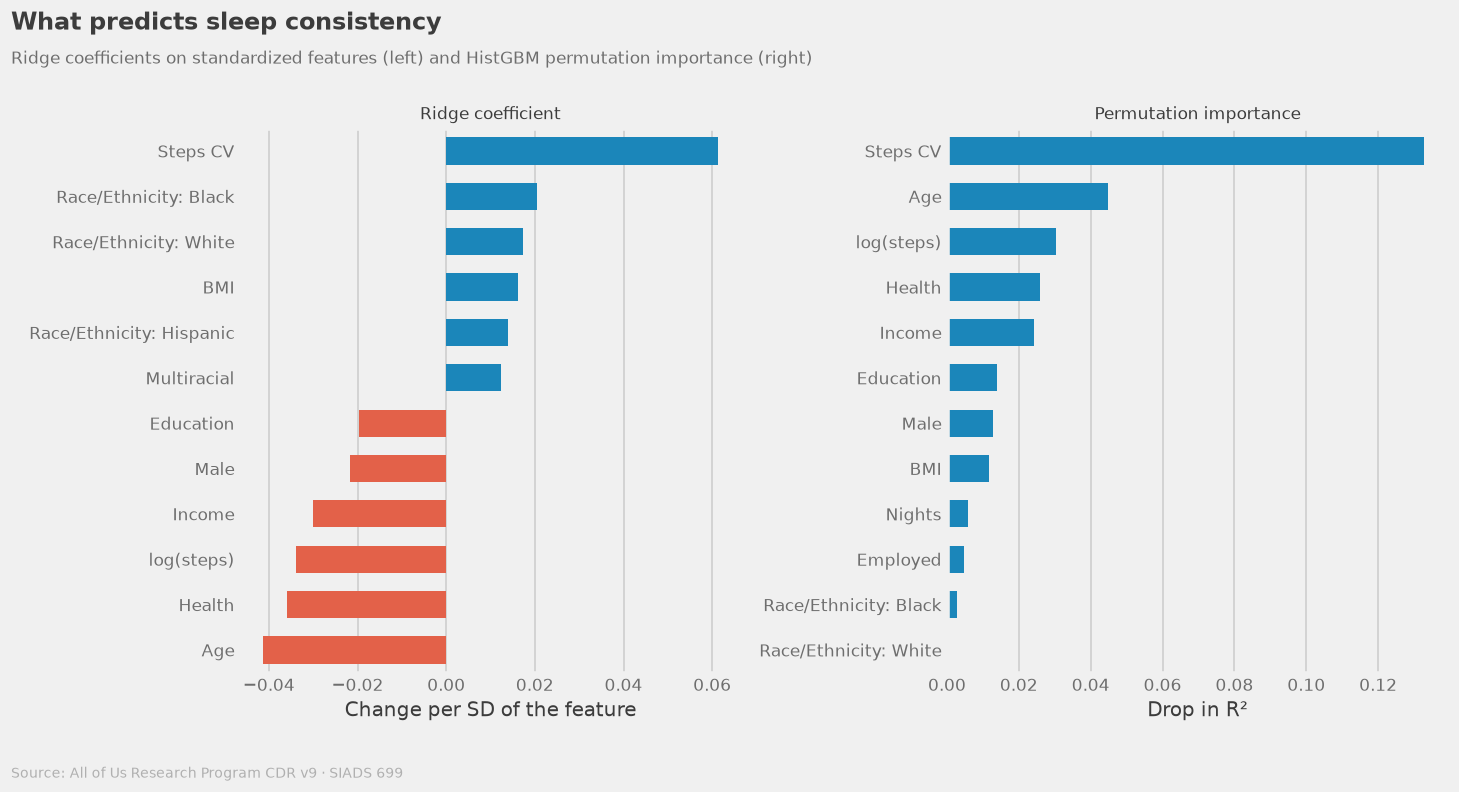

In [13]:
for target in TARGETS:
    X, y = XY[target]

    ridge = models.get_model("Ridge")
    ridge.fit(X, y)
    importances = models.permutation_scores(X, y, models.get_model("HistGBM"))

    # Direction and reliance on one figure: they answer different questions and
    # where they disagree is itself worth seeing.
    display(viz.plot_interpretation(models.coefficients(ridge, X.columns), importances,
                                    target_name=f"sleep {_short(target)}"))


No wear-time column appears in either top four, which is what the collinearity prune was for.
`n_valid_nights` stays in as a control rather than as a finding: Fitbit wearers are self-selected,
and how long someone keeps wearing one is not a sleep behaviour.

The two targets lean on different things. Duration is carried by activity level and person-level features:
`gender_Male`, `race_ethnicity_White` and `age`.
Consistency is carried by activity, with `steps_cv`.

### Is the model calibrated, or just weak?

A weak R² can mean two different things: predictions that are right on average but explain little,
or predictions that are systematically wrong somewhere in their range. Binning the out-of-fold
predictions and comparing each bin's mean prediction to its mean actual separates the two.


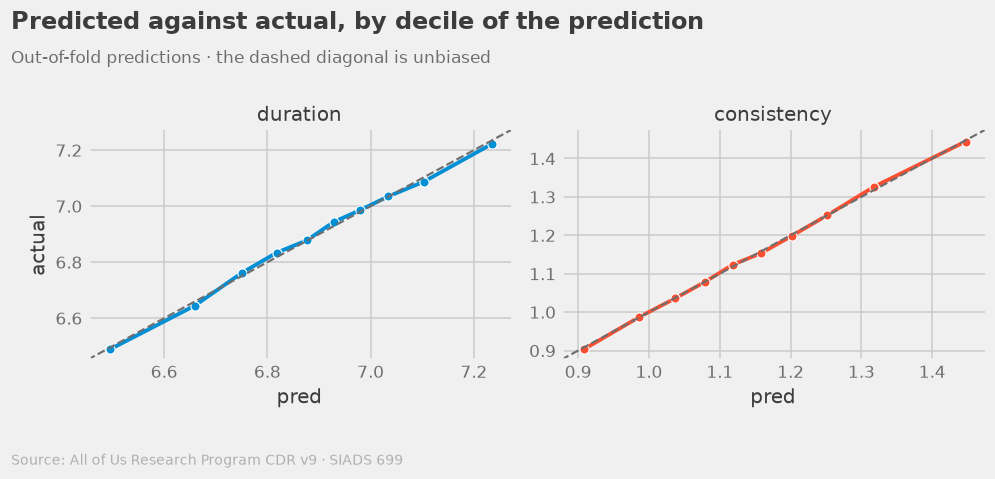

In [14]:
oof = {}
for target in TARGETS:
    X, y = XY[target]
    oof[_short(target)] = (y, models.oof_predictions(X, y, models.get_model("HistGBM")))

viz.plot_calibration(oof)


The alignment of out-of-fold prediction with actual suggest duration and consistency are unbiased with minimal deviations.

Neither gap is large enough to account for what the models leave unexplained, so the low R² is real
unexplained variance rather than avoidable bias. Sleep is driven by variables this model does not
carry.


---
## 7 · Fairness

Out-of-fold R² by subgroup. Uses R² rather than raw RMSE, because RMSE by subgroup mostly tracks that subgroup's own outcome variance.

Each subgroup's R² uses that subgroup's own mean as the denominator. Since R² = 1 − MSE/Var(group), a
group whose outcome varies less must be predicted more precisely to score the same.

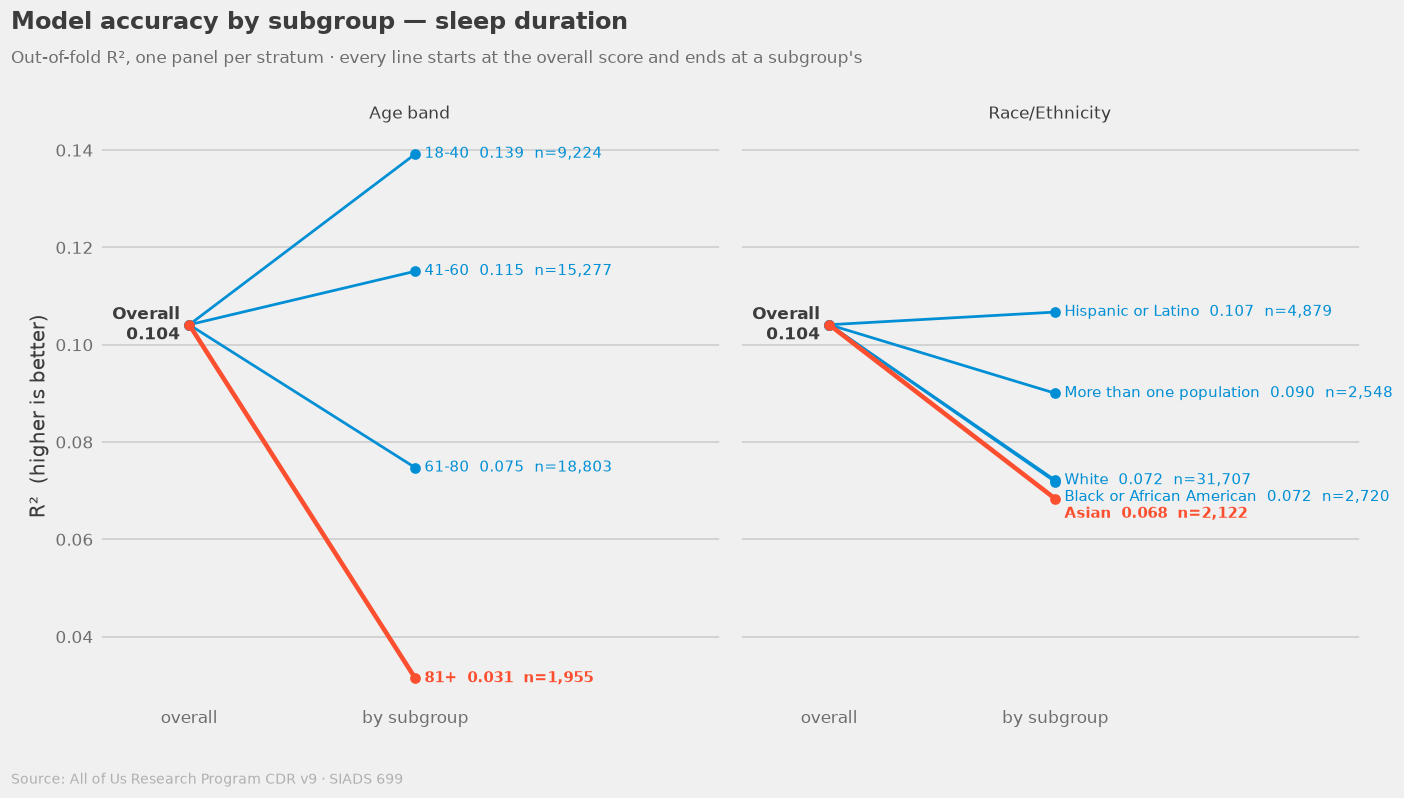

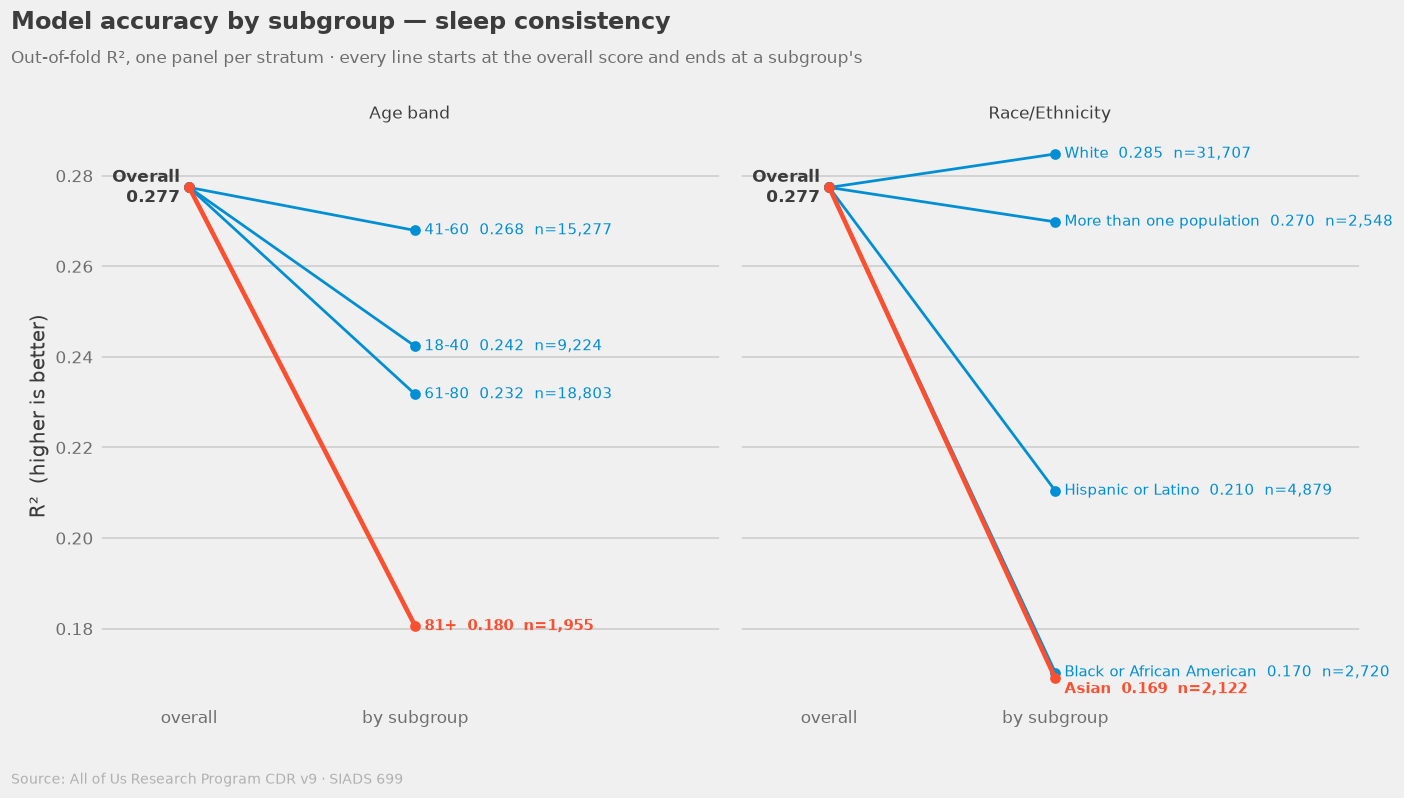

In [15]:
hgb = models.get_model("HistGBM")

# `Unknown` and `Other` are dropped: both are residual buckets rather than representative populations.
for target in TARGETS:
    fair = {col: models.fairness_cv(model_df, target, hgb, col)
            for col in models.GROUP_COLS}
    display(viz.plot_fairness_slope(fair, target_name=f"sleep {_short(target)}",
                                    exclude=("Unknown", "Other")))


---
## 8 · Phenotypes

What kinds of sleepers are there? KMeans over four columns of descriptions of the participant's nights:

| column | carries |
|---|---|
| `mean_sleep_hrs` | how much |
| `std_sleep_hrs` | how variable |
| `pct_short_sleep` | share of nights under 6 h |
| `pct_long_sleep` | share of nights over 9 h |

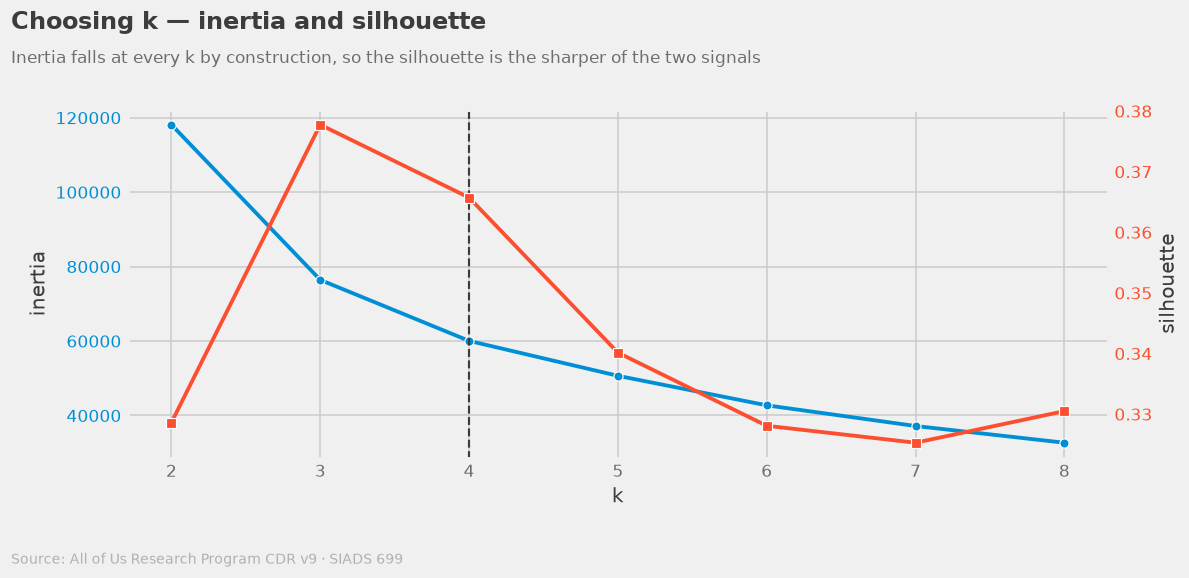

,inertia,silhouette
k,,
2,118102.948,0.329
3,76419.919,0.378
4,60039.430,0.366
5,50656.426,0.340
6,42727.704,0.328
7,37173.826,0.325
8,32682.550,0.330


In [16]:
X_cluster = cluster.prepare_cluster_matrix(model_df)
assert X_cluster.isna().sum().sum() == 0, \
    "cluster matrix has missing values — nothing here imputes them"

scan = cluster.scan_k(X_cluster)

assert scan.loc[4, "silhouette"] > 0.30, "k=4 clusters are less separated than when this was written"

display(viz.plot_cluster_scan(scan, chosen_k=4))
scan.round(3)


### Choosing k

The silhouette prefers k=3 (0.378), with k=4 close behind (0.366).

k=4 is taken for the extra split. In this instance k is a choice, not rigidly determined. At k=3 the short sleepers are one group; at k=4
they separate into a regular and a variable one.

In [17]:
labels = cluster.assign_clusters(model_df, k=4)

# KMeans label integers depend on the seed, so cluster.name_clusters() resolves the four archetypes
# from centroid position instead — the table below comes out in the same order every run.
assert set(labels.dropna().unique()) == set(cluster.PHENOTYPES), "naming rule left a cluster unnamed"

profile = cluster.cluster_profile(model_df, labels)
profile.round(2)

,N,pct,mean_sleep_hrs,std_sleep_hrs,pct_short_sleep,pct_long_sleep,iqr_sleep_hrs,mean_daily_steps,age,bmi,n_valid_nights,pct_female
phenotype,,,,,,,,,,,,
Consistent Good Sleepers,17796,39.3,7.13,0.95,0.12,0.03,1.14,7787.94,58.47,27.62,792.30,0.67
Chronic Short & Variable,10703,23.6,6.89,1.44,0.29,0.08,1.97,6180.99,52.67,30.82,576.14,0.73
Short but Regular,12186,26.9,6.13,1.07,0.47,0.01,1.43,7471.58,58.65,30.35,628.21,0.56
Variable Long Sleepers,4574,10.1,7.97,1.48,0.11,0.25,1.97,5386.09,54.16,30.01,565.48,0.76


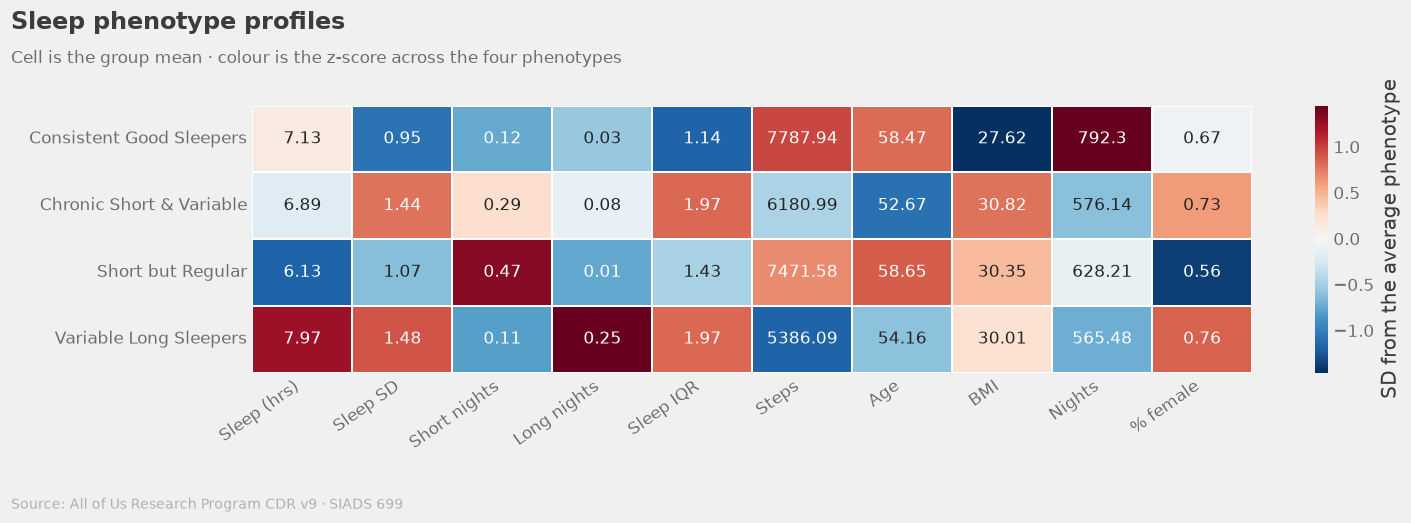

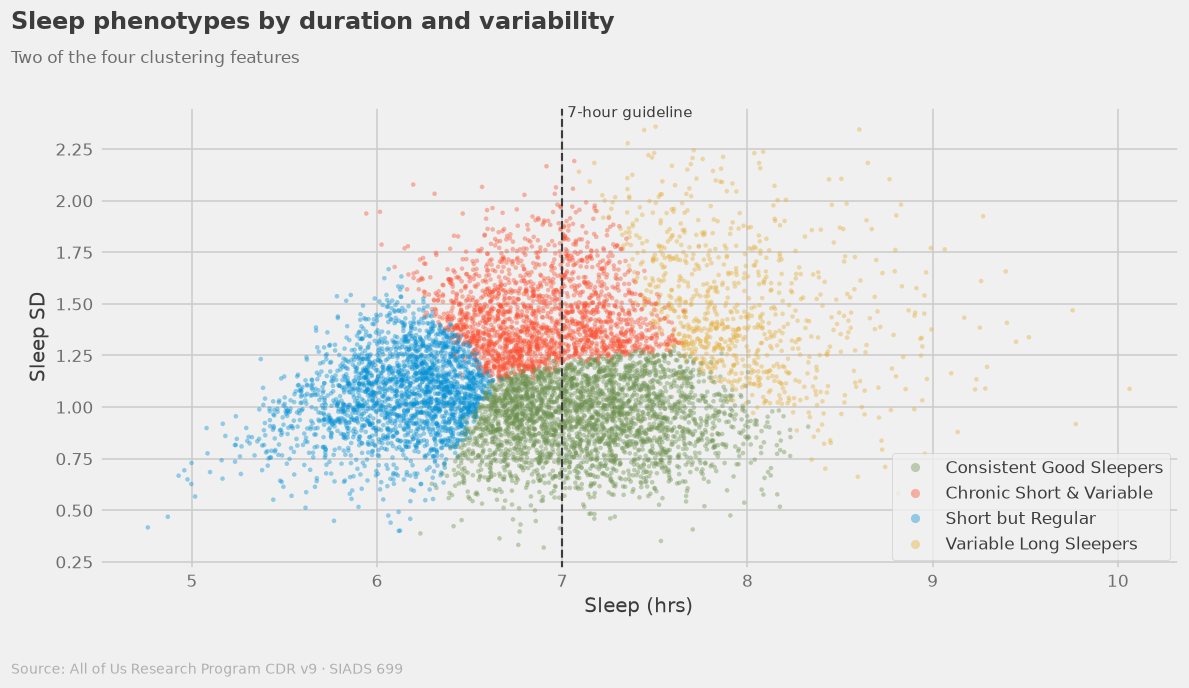

In [18]:
display(viz.plot_cluster_heatmap(profile))
display(viz.plot_cluster_scatter(model_df, labels))

**What this does not establish:** 
1. KMeans imposes spherical, equal-variance groups on what the scatter
shows to be one continuous cloud, so a participant near a boundary is not meaningfully in either
group. 
2. The clusters describe measured behaviour over the tracked window, not cause. 
3. Three of the four features are functions of the same nightly distribution, so the solution is close to a
two-dimensional summary of duration and variability.
